## Scenario 1

### SVD

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [73]:
df = pd.read_csv("ratings.csv")

df = df.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id"
})

df.head()

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [74]:
# Drop timestamp (not needed)
df = df.drop('timestamp', axis=1)

# Check dataset info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   100836 non-null  int64  
 1   movie_id  100836 non-null  int64  
 2   rating    100836 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.3 MB
None
             user_id       movie_id         rating
count  100836.000000  100836.000000  100836.000000
mean      326.127564   19435.295718       3.501557
std       182.618491   35530.987199       1.042529
min         1.000000       1.000000       0.500000
25%       177.000000    1199.000000       3.000000
50%       325.000000    2991.000000       3.500000
75%       477.000000    8122.000000       4.000000
max       610.000000  193609.000000       5.000000


In [75]:
user_item_matrix = df.pivot(index='user_id', columns='movie_id', values='rating')

user_item_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
user_mean = user_item_matrix.mean(axis=1)

matrix_centered = user_item_matrix.sub(user_mean, axis=0)

# IMPORTANT: Create mask BEFORE filling NaN
mask = ~np.isnan(user_item_matrix.values)

# Fill NaN for SVD
matrix_centered_filled = matrix_centered.fillna(0)
print(matrix_centered_filled.head())

movie_id    1       2         3       4       5         6       7       \
user_id                                                                  
1        -0.366379     0.0 -0.366379     0.0     0.0 -0.366379     0.0   
2         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
3         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
4         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
5         0.363636     0.0  0.000000     0.0     0.0  0.000000     0.0   

movie_id  8       9       10      ...  193565  193567  193571  193573  193579  \
user_id                           ...                                           
1            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
2            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
3            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
4            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.

In [77]:
k_values = [5, 10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)

    U = svd.fit_transform(matrix_centered_filled)
    Sigma = np.diag(svd.singular_values_)
    VT = svd.components_

    reconstructed = np.dot(np.dot(U, Sigma), VT)
    reconstructed = reconstructed + user_mean.values.reshape(-1, 1)

    # Optional: clip ratings
    reconstructed = np.clip(reconstructed, 1, 5)

    rmse = np.sqrt(mean_squared_error(
        user_item_matrix.values[mask],
        reconstructed[mask]
    ))

    rmse_list.append(rmse)
    print(f"k = {k}, RMSE = {rmse}")


k = 5, RMSE = 1.181578638984869
k = 10, RMSE = 1.1813339780482597
k = 20, RMSE = 1.176311714650067
k = 30, RMSE = 1.1771806500307553
k = 40, RMSE = 1.1790102242263705
k = 50, RMSE = 1.1801534081978466


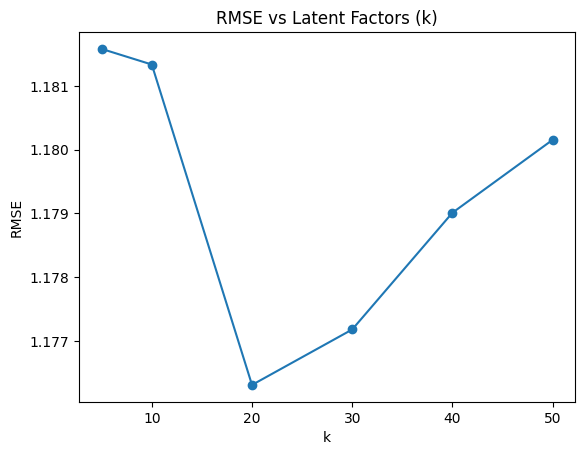

In [78]:
plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

In [79]:
best_k = k_values[np.argmin(rmse_list)]
print("Best k:", best_k)

Best k: 20


In [80]:
svd = TruncatedSVD(n_components=best_k, random_state=42)

U = svd.fit_transform(matrix_centered_filled)
Sigma = np.diag(svd.singular_values_)
VT = svd.components_

reconstructed = np.dot(np.dot(U, Sigma), VT)
reconstructed = reconstructed + user_mean.values.reshape(-1, 1)

# Proper clipping (REQUIRED)
reconstructed = np.clip(reconstructed, 1, 5)

reconstructed_matrix = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)


In [81]:
actual = user_item_matrix.values
predicted = reconstructed_matrix.values

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print("Final RMSE:", rmse)
print("Final MAE:", mae)

Final RMSE: 1.176311714650067
Final MAE: 0.9193263393735355


In [82]:
def recommend_movies(user_id, n=5):
    user_row = reconstructed_matrix.loc[user_id]

    rated_movies = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(rated_movies)

    # ONLY sorting (NO clipping)
    top_n = recommendations.sort_values(ascending=False).head(n)

    return top_n
# Example
print("\nTop Recommendations for User 1:")
print(recommend_movies(2, 5))


Top Recommendations for User 1:
movie_id
158     4.783210
1391    4.740656
10      4.710681
153     4.708640
367     4.707177
Name: 2, dtype: float64


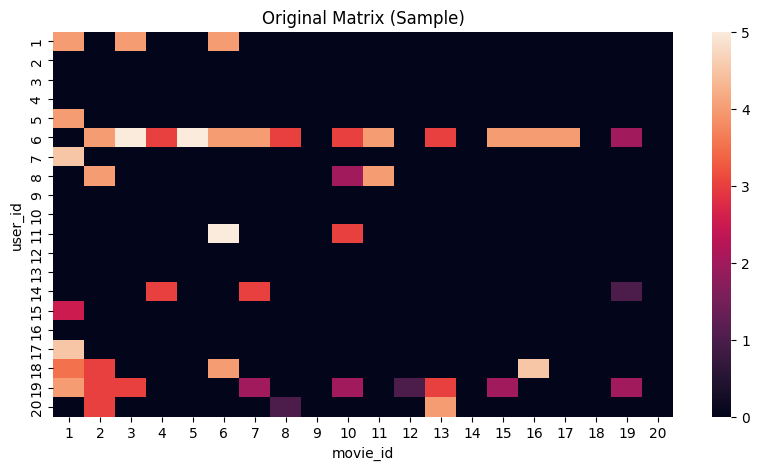

In [83]:
# Heatmap (Original)
plt.figure(figsize=(10,5))
sns.heatmap(user_item_matrix.fillna(0).iloc[:20, :20])
plt.title("Original Matrix (Sample)")
plt.show()


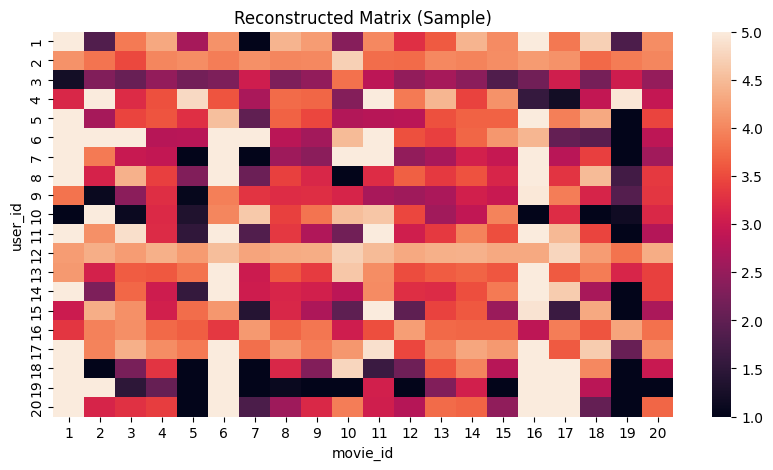

In [84]:

# Heatmap (Reconstructed)
plt.figure(figsize=(10,5))
sns.heatmap(reconstructed_matrix.iloc[:20, :20])
plt.title("Reconstructed Matrix (Sample)")
plt.show()

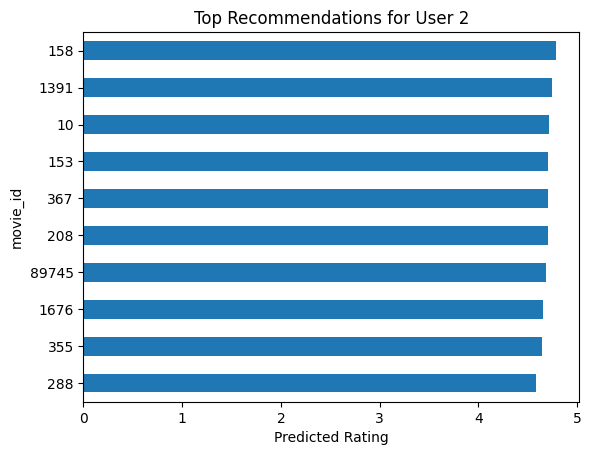

In [85]:
# Top Recommendations Plot
user_id = 2
top_movies = recommend_movies(user_id, 10)

plt.figure()
top_movies.sort_values().plot(kind='barh')
plt.title(f"Top Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()

## Scenario 2

### NMF

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [89]:
ratings = pd.read_csv("ratings.csv")

ratings = ratings.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id"
})

ratings = ratings.drop("timestamp", axis=1)

print(ratings.head())

   user_id  movie_id  rating
0        1         1     4.0
1        1         3     4.0
2        1         6     4.0
3        1        47     5.0
4        1        50     5.0


In [90]:
user_item = ratings.pivot(index='user_id', columns='movie_id', values='rating')

print("Matrix shape:", user_item.shape)

Matrix shape: (610, 9724)


In [91]:
mask = ~np.isnan(user_item.values)

user_item_filled = user_item.fillna(0)

In [92]:
k = 20  # latent features

nmf_model = NMF(n_components=k, init='nndsvd', random_state=42, max_iter=300)

W = nmf_model.fit_transform(user_item_filled)
H = nmf_model.components_

print("User-feature matrix shape:", W.shape)
print("Item-feature matrix shape:", H.shape)

User-feature matrix shape: (610, 20)
Item-feature matrix shape: (20, 9724)


In [93]:
reconstructed = np.dot(W, H)

# Clip values to rating range
reconstructed = np.clip(reconstructed, 1, 5)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item.index,
    columns=user_item.columns
)


In [94]:
actual = user_item.values
predicted = reconstructed_df.values

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("NMF RMSE:", rmse)

NMF RMSE: 2.1552943169863035


In [95]:

def recommend_nmf(user_id, n=5):
    user_row = reconstructed_df.loc[user_id]

    rated_movies = user_item.loc[user_id].dropna().index
    recommendations = user_row.drop(rated_movies)

    top_n = recommendations.sort_values(ascending=False).head(n)
    return top_n


# Example
print("\nTop Recommendations for User 1:")
print(recommend_nmf(1, 5))


Top Recommendations for User 1:
movie_id
589     4.590075
1200    4.426531
2762    3.356399
1036    3.260128
1374    3.201273
Name: 1, dtype: float64


In [104]:
def precision_at_k(user_id, k=5, threshold=3.0):
    recommended = recommend_nmf(user_id, k).index
    relevant = user_item.loc[user_id][user_item.loc[user_id] >= threshold].index

    hits = len(set(recommended) & set(relevant))
    return hits / k


print("Precision@5:", precision_at_k(1, 5))

Precision@5: 0.0


In [105]:
def recall_at_k(user_id, k=5, threshold=3.0):
    recommended = recommend_nmf(user_id, k).index
    relevant = user_item.loc[user_id][user_item.loc[user_id] >= threshold].index

    hits = len(set(recommended) & set(relevant))

    if len(relevant) == 0:
        return 0

    return hits / len(relevant)


print("Recall@5:", recall_at_k(1, 5))

Recall@5: 0.0


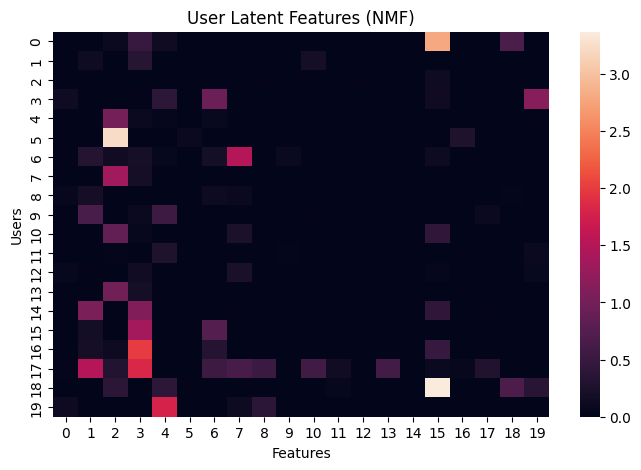

In [99]:
# Latent Features (Users)
plt.figure(figsize=(8,5))
sns.heatmap(W[:20])
plt.title("User Latent Features (NMF)")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

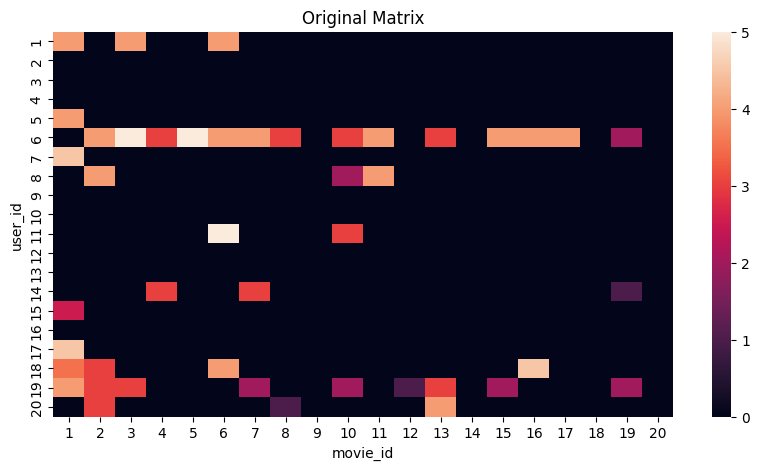

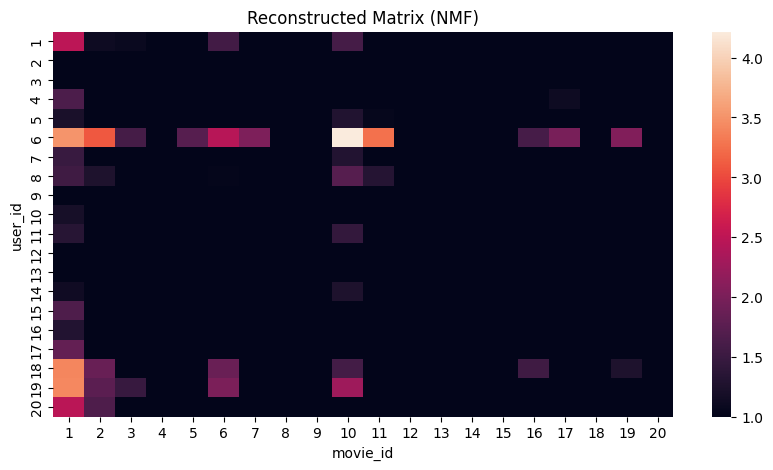

In [100]:

# Original Matrix (Sample)
plt.figure(figsize=(10,5))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()
# Reconstructed Matrix (Sample)
plt.figure(figsize=(10,5))
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

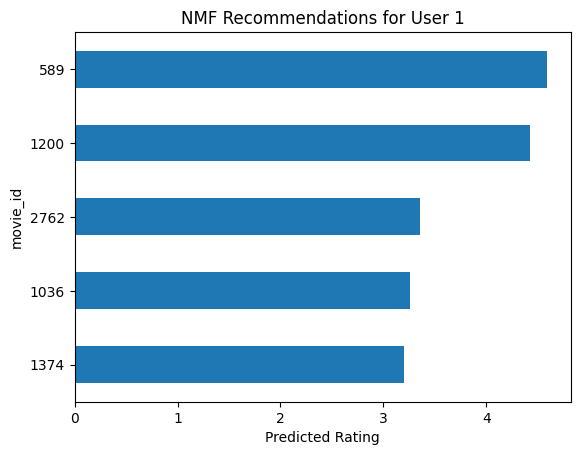

In [102]:
# Recommendation Plot
user_id = 1
top_movies = recommend_nmf(user_id, 5)

plt.figure()
top_movies.sort_values().plot(kind='barh')
plt.title(f"NMF Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()

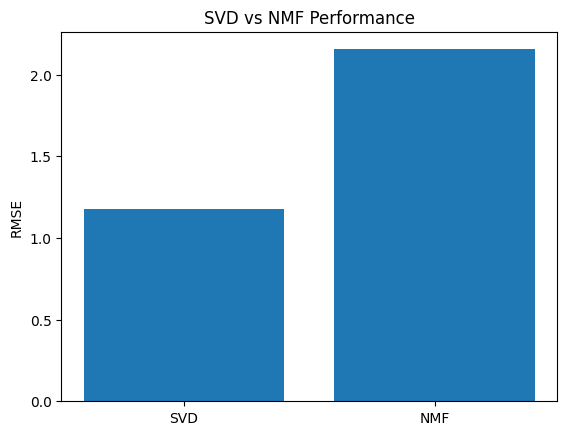

In [107]:
svd_rmse = 1.176  # replace with your actual SVD RMSE
nmf_rmse = rmse

plt.figure()
plt.bar(['SVD', 'NMF'], [svd_rmse, nmf_rmse])
plt.title("SVD vs NMF Performance")
plt.ylabel("RMSE")
plt.show()